In [24]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\A\raw_data.csv")

cols = data.columns[:-1].to_list() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()

whole = data.copy()

data = data.iloc[0:100,:]

validation = whole.iloc[100:200,:]

# print(len(whole))
# print(len(data))
# print(len(validation))
print(data)

          X1        X2        X3        X4        X5        X6        X7  \
0  -0.389291 -0.522553 -0.082890  0.707455 -0.399593 -1.698661 -0.241779   
1  -0.071352  1.092969 -0.423445 -0.115710 -0.910926  0.509450  1.050120   
2  -0.540340  0.187717 -1.252094 -1.662977 -1.391169 -0.600192 -0.278993   
3   2.273080  0.968238  0.566474  1.260181  0.265837  0.716076  0.052798   
4  -0.736328  0.243837 -0.451091  0.100519 -0.877122 -0.656085 -0.763945   
..       ...       ...       ...       ...       ...       ...       ...   
95 -1.254165 -0.498231  0.949437  0.859386  0.874066  0.480748  0.080558   
96 -0.777785  1.525368  0.448661  0.211203 -0.431611 -0.450576 -1.283347   
97  0.830851 -0.539689 -0.612746 -0.105013 -0.923125 -0.397344  0.283417   
98 -0.009443 -0.814236 -0.952229  0.608628  0.105333 -0.858748 -0.057111   
99 -0.846695 -1.473001 -1.397326 -0.427048 -0.808888 -0.551516  2.008068   

          X8        X9       X10         Y  
0  -0.354374  0.087120  1.099313 -1.333263

In [25]:
X = data[cols]

XTX = X.T @ X

y = data["Y"]

# beta
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("手算:")
print(beta)
print("---------------------------------------------")

# 用套件驗證
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

print("套件驗證:")
print(result.params)

手算:
0    1.133339
1    0.658043
2    0.485085
3    0.419325
4    0.133598
5   -0.038859
6   -0.091168
7   -0.183425
8    0.140706
9   -0.141512
dtype: float64
---------------------------------------------
套件驗證:
X1     1.133339
X2     0.658043
X3     0.485085
X4     0.419325
X5     0.133598
X6    -0.038859
X7    -0.091168
X8    -0.183425
X9     0.140706
X10   -0.141512
dtype: float64


In [26]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [27]:
y

tensor([-1.3333,  0.2089, -2.8346,  3.6780, -2.8298, -1.4441, -0.2504,  0.0141,
         2.7344,  1.8741, -0.3152,  1.1650, -1.9471, -0.0651,  1.0187, -0.3715,
         3.3176, -2.1629, -2.4812,  0.9455,  0.9941,  1.5116, -3.6084,  0.2305,
        -2.0606,  4.5125,  1.0030, -2.0064,  2.9881, -1.3732,  1.6113,  1.5190,
         0.1458, -0.4459,  2.6421,  5.2490,  1.8355,  1.4583, -1.3639, -1.2602,
         0.3769, -4.1973, -1.3836, -1.2786, -3.1567,  1.6937, -3.1321, -4.0850,
        -2.6984,  2.5701,  1.0439, -1.3364,  1.6759, -3.4013, -4.2153, -0.2734,
         2.8816,  3.9124, -0.9089, -0.1139, -1.3521, -0.2907,  3.4177,  4.3957,
         3.1068, -1.0420, -2.5074, -5.0696, -1.8969,  2.2503,  2.5992,  0.1654,
        -3.9632, -0.5928, -0.3372, -2.4204,  3.7442, -0.0810, -2.1942, -0.4663,
        -1.7868,  1.6005,  2.9754, -2.2764, -0.5585, -1.7894, -2.1878, -2.1403,
        -5.2628,  1.6777, -1.0632,  0.8001, -1.6867,  1.7672,  4.7750, -0.6792,
         1.3843, -1.2357, -2.4944, -2.36

In [28]:
X

tensor([[-3.8929e-01, -5.2255e-01, -8.2890e-02,  7.0745e-01, -3.9959e-01,
         -1.6987e+00, -2.4178e-01, -3.5437e-01,  8.7120e-02,  1.0993e+00],
        [-7.1352e-02,  1.0930e+00, -4.2345e-01, -1.1571e-01, -9.1093e-01,
          5.0945e-01,  1.0501e+00,  2.0957e+00,  5.0296e-01, -1.3516e+00],
        [-5.4034e-01,  1.8772e-01, -1.2521e+00, -1.6630e+00, -1.3912e+00,
         -6.0019e-01, -2.7899e-01, -1.0767e-01, -4.3990e-01, -1.3394e+00],
        [ 2.2731e+00,  9.6824e-01,  5.6647e-01,  1.2602e+00,  2.6584e-01,
          7.1608e-01,  5.2798e-02, -1.2278e+00,  1.2733e-02, -1.6229e+00],
        [-7.3633e-01,  2.4384e-01, -4.5109e-01,  1.0052e-01, -8.7712e-01,
         -6.5608e-01, -7.6395e-01,  1.0757e+00, -7.9220e-01, -1.0452e+00],
        [-8.2122e-01, -6.8173e-01, -1.2879e-01, -7.7499e-01,  4.6830e-01,
          6.6172e-01, -1.6317e-01, -9.5763e-01,  1.0851e-01,  3.8219e-01],
        [-2.5623e-01,  3.8613e-01, -4.2665e-01, -4.2743e-01,  4.5230e-01,
          1.7889e+00,  1.1505e+0

In [29]:
import torch.nn as nn

embedding_dim = len(data)
dk = 4

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [31]:
optimizer = torch.optim.Adam(

    [wq,wk], # wv

    # +list(proj.parameters())

    # +list(linear.parameters()),

    lr=0.001

)

In [32]:
import numpy as np
import torch.nn.functional as F

lam = 1

p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    A = attn @ attn.T + lam * I

    # beta
    beta = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
    y_hat,
    y
    )


    if epoch == 0:
        initial_attn = attn.detach().clone()

        # mean_initial_attn = initial_attn.mean(dim=0)

        # print(E.shape)

        # print(Q.shape)

        # print(K.shape)

        # print(scores.shape)

        # print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    final_attn = attn.clone()
    
    A = attn @ attn.T + lam * I

    # beta
    beta1 = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

print("訓練完之後的beta:")
print(beta1)

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



torch.Size([100])
torch.Size([100])
訓練完之後的beta:
tensor([ 1.1166,  0.6533,  0.4806,  0.4141,  0.1337, -0.0356, -0.0974, -0.1794,
         0.1410, -0.1428])


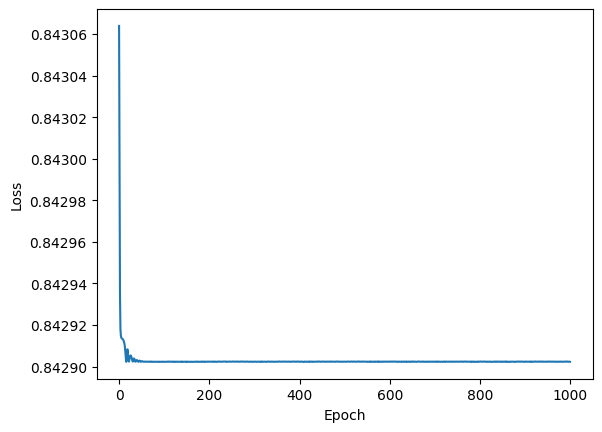

In [33]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

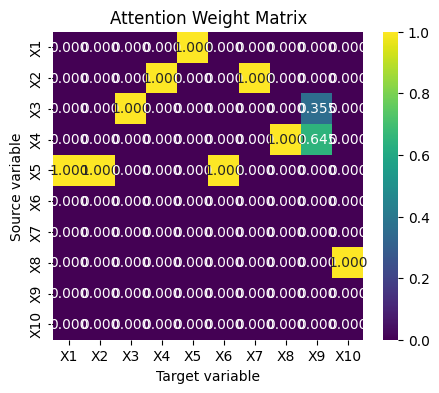

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

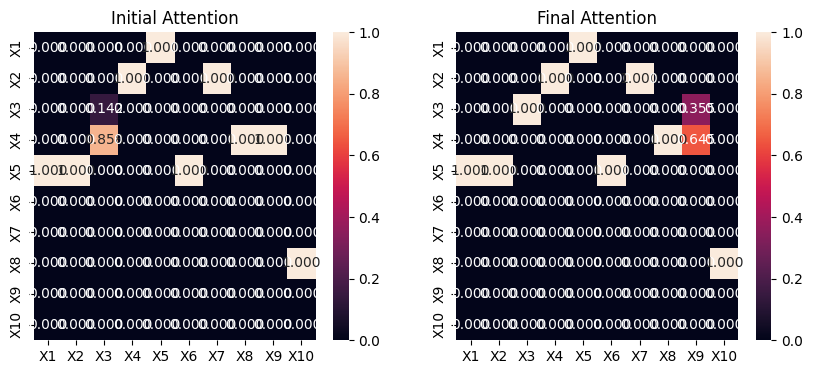

In [35]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()